In [10]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

file_path = r'F:\3д баловство\data.xlsx'
df = pd.read_excel(file_path)

# код обработки данных
temp_row_CaSO4 = df.iloc[:, 0].values
NaCl_conc_row = df.iloc[:, 1].values
solubility_row_CaSO4 = df.iloc[:, 2].values  # Растворимость CaSO4 (моль/кг)

# Молярная масса CaSO4
M_CaSO4 = 136.14  # г/моль

# Пересчет растворимости в г/л (приблизительно, плотность раствора ~1 кг/л)
solubility_g_per_L = solubility_row_CaSO4 * M_CaSO4

# Создание подграфиков: 1 строка, 2 колонки
fig = make_subplots(
    rows=1, 
    cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('Растворимость, моль/кг', 'Растворимость, г/л'),
    horizontal_spacing=0.1
)

# Левый график: растворимость в моль/кг
fig.add_trace(
    go.Scatter3d(
        x=temp_row_CaSO4,
        y=NaCl_conc_row,
        z=solubility_row_CaSO4,
        mode='markers',
        marker=dict(
            size=4,
            color=solubility_row_CaSO4,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(
                title="моль/кг",
                x=0.45,
                y=0.5,
                len=0.6
            )
        ),
        text=[f"T: {t:.2f} K<br>NaCl: {n:.4f} моль/кг<br>Растворимость: {s:.4f} моль/кг" 
              for t, n, s in zip(temp_row_CaSO4, NaCl_conc_row, solubility_row_CaSO4)],
        hoverinfo='text',
        name='моль/кг'
    ),
    row=1, col=1
)

# Правый график: растворимость в г/л
fig.add_trace(
    go.Scatter3d(
        x=temp_row_CaSO4,
        y=NaCl_conc_row,
        z=solubility_g_per_L,
        mode='markers',
        marker=dict(
            size=4,
            color=solubility_g_per_L,
            colorscale='Plasma',
            showscale=True,
            colorbar=dict(
                title="г/л",
                x=0.95,
                y=0.5,
                len=0.6
            )
        ),
        text=[f"T: {t:.2f} K<br>NaCl: {n:.4f} моль/кг<br>Растворимость: {s:.2f} г/л" 
              for t, n, s in zip(temp_row_CaSO4, NaCl_conc_row, solubility_g_per_L)],
        hoverinfo='text',
        name='г/л'
    ),
    row=1, col=2
)

# Обновление настроек для левого графика
fig.update_scenes(
    dict(
        xaxis_title='Температура, K',
        yaxis_title='Концентрация NaCl, моль/кг',
        zaxis_title='Растворимость, моль/кг',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    row=1, col=1
)

# Обновление настроек для правого графика
fig.update_scenes(
    dict(
        xaxis_title='Температура, K',
        yaxis_title='Концентрация NaCl, моль/кг',
        zaxis_title='Растворимость, г/л',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    row=1, col=2
)

# Общие настройки
fig.update_layout(
    title={
        'text': 'Растворимость CaSO₄ в зависимости от температуры и концентрации NaCl',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    width=1600,
    height=700,
    showlegend=False
)

# Конфигурация для полноэкранного режима
config = {
    'scrollZoom': True,
    'displayModeBar': True,
    'responsive': True,
    'displaylogo': False
}

# Сохранение в HTML файл
output_path = r'F:\Термодинамика процесса гидролиза\CASO4 sol\CaSO4_solubility_3d.html'
fig.write_html(output_path, config=config, include_plotlyjs='cdn',)

print(f"График сохранен в: {output_path}")
print(f"Диапазон растворимости:")
print(f"  - в моль/кг: {solubility_row_CaSO4.min():.4f} - {solubility_row_CaSO4.max():.4f}")
print(f"  - в г/л: {solubility_g_per_L.min():.2f} - {solubility_g_per_L.max():.2f}")

График сохранен в: F:\Термодинамика процесса гидролиза\CASO4 sol\CaSO4_solubility_3d.html
Диапазон растворимости:
  - в моль/кг: 70.5000 - 86.7000
  - в г/л: 9597.87 - 11803.34


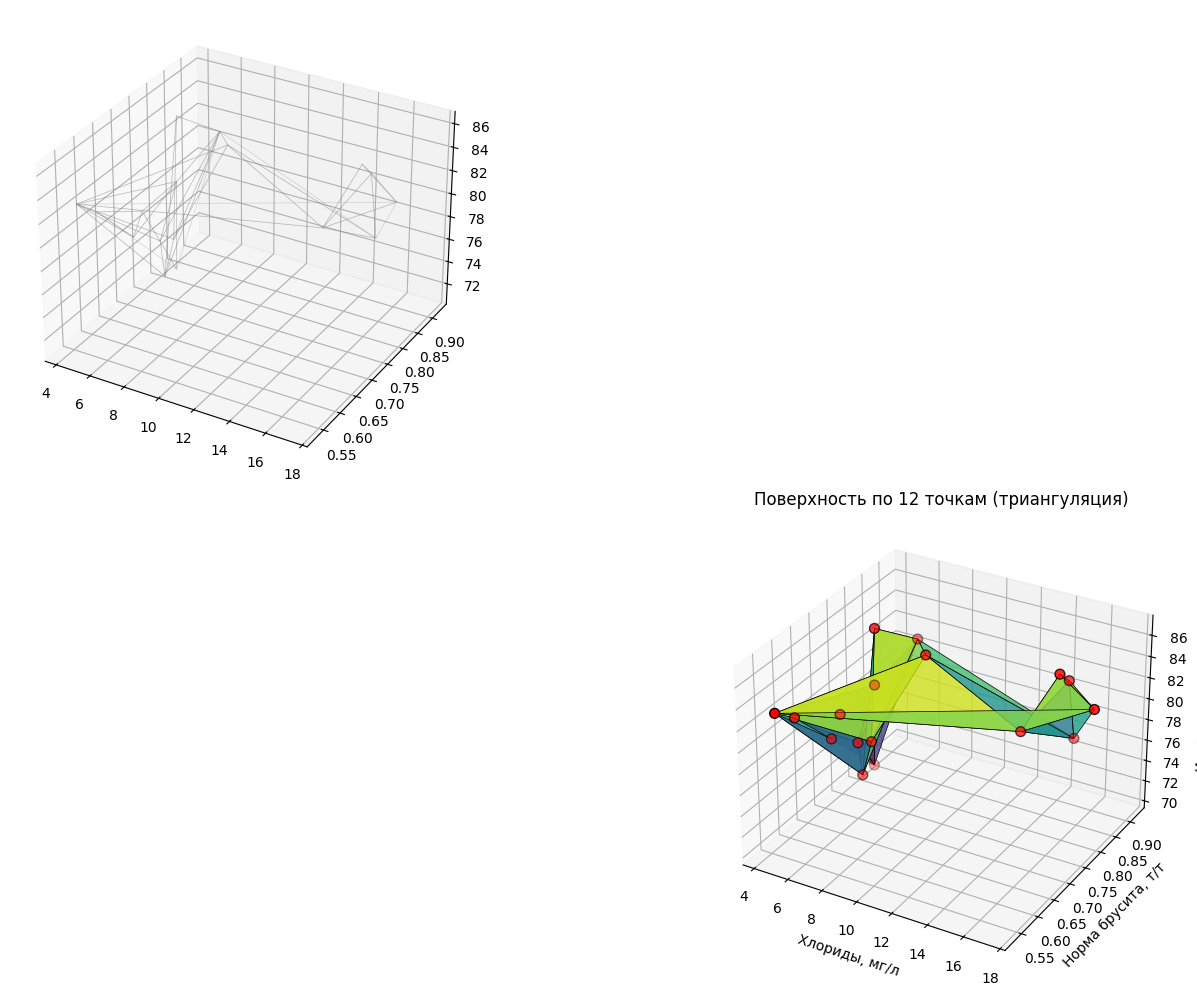


Статистика по данным:
  - количество точек: 17
  - извлечение золота: 70.5% - 86.7%
  - среднее: 79.6%
  - стандартное отклонение: 4.2%


In [20]:
from scipy.interpolate import LinearNDInterpolator, CloughTocher2DInterpolator
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.tri import Triangulation, CubicTriInterpolator

# Загрузка данных
file_path = r'F:\3д баловство\data.xlsx'
df = pd.read_excel(file_path)

# Считывание данных
chlorides = df.iloc[:, 0].values
brucite = df.iloc[:, 1].values
gold_recovery = df.iloc[:, 2].values

# Создание триангуляции Делоне
tri = Delaunay(np.column_stack([chlorides, brucite]))

# Создание сетки для визуализации
chlorides_grid = np.linspace(chlorides.min(), chlorides.max(), 100)
brucite_grid = np.linspace(brucite.min(), brucite.max(), 100)
chlorides_mesh, brucite_mesh = np.meshgrid(chlorides_grid, brucite_grid)
grid_points = np.column_stack([chlorides_mesh.ravel(), brucite_mesh.ravel()])

# Методы интерполяции на основе триангуляции
methods = {
    'Линейная интерполяция (триангуляция)': LinearNDInterpolator(tri, gold_recovery),
    'Кубическая интерполяция (Clough-Tocher)': CloughTocher2DInterpolator(tri, gold_recovery),
}

# Визуализация
fig = plt.figure(figsize=(15, 10))

# График 1: Исходные данные с триангуляцией (wireframe)
ax1 = fig.add_subplot(2, 2, 1, projection='3d')

# Отображение треугольников
for simplex in tri.simplices:
    # Получаем координаты вершин треугольника
    x_tri = [chlorides[i] for i in simplex] + [chlorides[simplex[0]]]
    y_tri = [brucite[i] for i in simplex] + [brucite[simplex[0]]]
    z_tri = [gold_recovery[i] for i in simplex] + [gold_recovery[simplex[0]]]
    ax1.plot(x_tri, y_tri, z_tri, color='gray', alpha=0.3, linewidth=0.5)


# График: поверхность по исходным точкам (без интерполяции)
ax = fig.add_subplot(2, 2, 4, projection='3d')

surf = ax.plot_trisurf(chlorides, brucite, gold_recovery,
                       triangles=tri.simplices,
                       cmap='viridis',
                       edgecolor='black',
                       linewidth=0.5,
                       alpha=0.8)

ax.scatter(chlorides, brucite, gold_recovery,
           c='red', s=50, edgecolors='black')

ax.set_title('Поверхность по 12 точкам (триангуляция)', fontsize=12)
ax.set_xlabel('Хлориды, мг/л')
ax.set_ylabel('Норма брусита, т/т')
ax.set_zlabel('Извлечение Au, %')


plt.tight_layout()
plt.show()

print(f"\nСтатистика по данным:")
print(f"  - количество точек: {len(chlorides)}")
print(f"  - извлечение золота: {gold_recovery.min():.1f}% - {gold_recovery.max():.1f}%")
print(f"  - среднее: {np.mean(gold_recovery):.1f}%")
print(f"  - стандартное отклонение: {np.std(gold_recovery):.1f}%")